In [13]:
# Activar
#!pip -q install seaborn

In [2]:
import os
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# VISUALIZACIÓN CON SEABORN

- <a href='#1.'>I. Gráfico de barras</a>
     - <a href='#1.1.'>1.1. Barras simples: Bar chart</a>
     - <a href='#1.2.'>1.2. Barras agrupadas o múltiples: Clustered bar chart</a> 
     - <a href='#1.3.'>1.3. Barras apiladas: Stack bar chart</a>
- <a href='#2.'>II. Proporciones</a>
     - <a href='#2.1.'>2.1. Gráfico de pie</a>
     - <a href='#2.2.'>2.2. Gráfico de donuts</a>
- <a href='#3.'>III. Distribuciones</a>
     - <a href='#3.1.'>3.1. Histogramas simples</a>
     - <a href='#3.2.'>3.2. Histogramas múltiples</a>
     - <a href='#3.3.'>3.3. Mapas de densidad</a>
     - <a href='#3.4.'>3.4. Diagrama de Cajas</a>
- <a href='#4.'>IV. Relaciones</a>
     - <a href='#4.1.'>4.1. Diagrama de Cajas</a>

# <a id ='1.'>I. Gráfico de barras</a>
* Este tipo de gráfico muestra los niveles de las variables y las variables según categorías o clasificaciones.

## <a id ='1.1.'>1.1. Barras simples: Bar chart</a>

* La siguiente base de datos incluye data de los módulos (200, 300 y 500) del periodo 2011 - 2019.

In [4]:
# Ruta para Windows o Mac
ruta_enaho = os.path.join("data", "enaho.dta")

# Leer el archivo Stata
enaho = pd.read_stata(ruta_enaho)
enaho.head(5)

,year,conglome,vivienda,hogar,ubigeo,codperso,dominio,estrato,panel,p203,...,acumulado,estud,educa,d_edu,exper,exper_2,tenure_2,edad_2,jefe,ubigeo_2
0,2011,0061,077,11,010701,04,selva,"de 4,001 a 10,000 viviendas",2.011006e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,2.0,4.0,NaN,361.0,familiar,010000
1,2011,0110,112,11,010705,05,selva,Área de empadronamiento rural - aer compuesto,2.011011e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,9.0,400.0,familiar,010000
2,2011,0090,076,11,010205,03,selva,Área de empadronamiento rural - aer compuesto,2.011009e+14,nieto,...,6.0,5.0,11.0,Secundaria completa,5.0,25.0,36.0,484.0,familiar,010000
3,2011,0118,080,11,010401,03,selva,Área de empadronamiento rural - aer simple,2.011012e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,6.0,36.0,NaN,529.0,familiar,010000
4,2011,3408,066,11,010402,03,selva,Área de empadronamiento rural - aer compuesto,2.011341e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,0.0,400.0,familiar,010000


In [16]:
# Para ver el tipo de empresas: 4 categorías de empresas y NaN
enaho['empresa']

0                     NaN
1            microempresa
2            microempresa
3                     NaN
4            gran empresa
               ...       
160767                NaN
160768       microempresa
160769    mediana empresa
160770                NaN
160771       microempresa
Name: empresa, Length: 160772, dtype: category
Categories (4, object): ['microempresa' < 'pequeña empresa' < 'mediana empresa' < 'gran empresa']

In [17]:
resas: 4 categorías de empresas y NaN
enaho['empresa']

SyntaxError: invalid syntax (2670313892.py, line 1)

**TIPOS DE EMPRESA:**
* Microbusinesses < 10 workers ;
* Small businesses (10-20 workers);
* Medium businesses (21-100 workers);
* Big Businesses (>100 workers)

**TIPS:**
* Seteamos primero el estilo de la figura

Text(0, 0.5, 'Número de Observaciones')

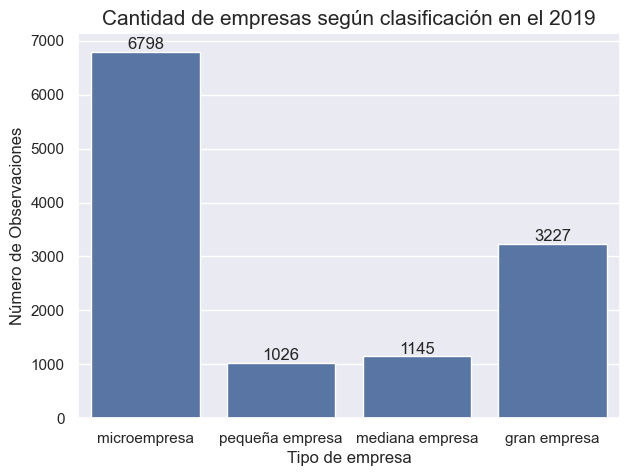

In [ ]:
# Barras verticales:

# Estilo
sns.set( style="darkgrid" )

#Tamaño de la figura
fig, ax = plt.subplots( figsize=(7,5) ) # Largo, Alto en pulgadas

# Gráfico de barras
# countplot es un método de Seaborn que permite crear gráficos de barras a partir de un DataFrame de Pandas.
x = sns.countplot( x="empresa", 
                  data=enaho[enaho['year'] == "2019" ] )

# Número de observaciones sobre cada barra: iteramos sobre cada barra del gráfico y colocamos el número de observaciones sobre cada barra.
for p in ax.patches:
    # Obtener la posición y la altura de la barra
    height = p.get_height()
    # Colocar el texto sobre la barra
    ax.text(
        p.get_x() + p.get_width() / 2.,  # Posición x del texto (centro de la barra)
        height + 0.1,                    # Posición y del texto (altura de la barra + 3)
        '{:1.0f}'.format(height),        # Texto a mostrar (altura de la barra formateada)
        ha="center",                      # Alineación horizontal del texto  
        va='bottom'                      # Alineación vertical del texto
    )

# plt: objeto o clase
# title/xlabel/ylabel: métodos de la clase plt  
plt.title('Cantidad de empresas según clasificación en el 2019', fontsize=15)
plt.xlabel('Tipo de empresa')
plt.ylabel('Número de Observaciones')


* Si queremos cambiar los nombres de una columna, se recomienda crear una nueva. No chancar la misma.

Text(0, 0.5, 'Tipo de empresa')

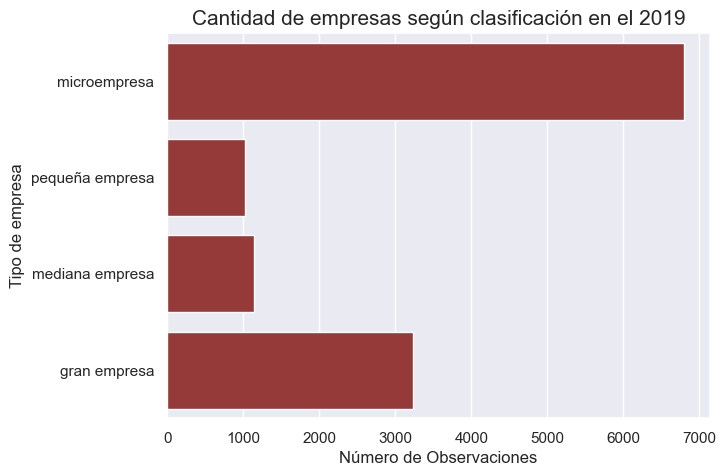

In [ ]:
# Barras horizontales:
sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(7,5))

x = sns.countplot(y = "empresa", data=enaho[enaho['year'] == "2019" ], color = 'brown')

plt.title('Cantidad de empresas según clasificación en el 2019', fontsize=15)
plt.xlabel('Número de Observaciones')
plt.ylabel('Tipo de empresa')

## <a id ='1.2.'>1.2. Barras agrupadas o múltiples: Clustered bar chart</a>

* Veamos la evolución de los negocios en el periodo 2017-2019.
* Con Seaborn podemos hacer lo que con Matplotit nos demoraría muchas líneas de código.

Text(0.01, 0.01, 'Fuente: Elboración propia - ENAHO (2011-2019)')

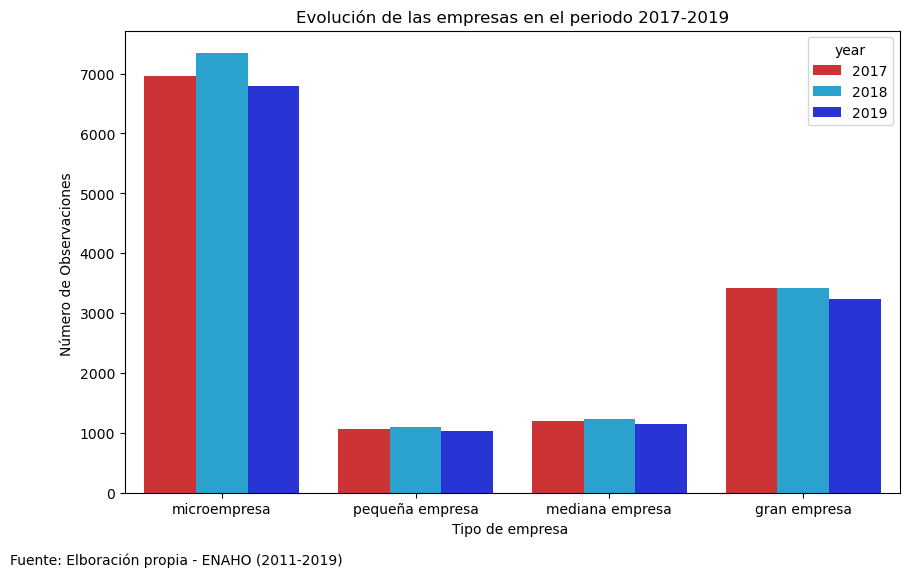

In [ ]:
# Barra agrupadas simples: cómo varía la variable empresa según el año.

# Me quedo con los datos de 2017 en adelante: Lo nombraremos base2
# Tener el cuenta el nombre porque será útil para los gráficos de Histogramas y de dispersión (Sección III: Distribuciones)

base2 = enaho[enaho['year'] > "2016" ]

fig, ax = plt.subplots(figsize=(10,6))

# Ploteo cruzado: cómo sea variable empresa varía según el año.
# hue: variable que cruzamos con la variable x, en este caso el año.
ax = sns.countplot(x="empresa", 
                   hue="year", 
                   linewidth=1, 
                   data=base2,
                   palette=["#e41a1c", "#10afe8", "#0c1bf2"]) # Colores con el código Picker

plt.title('Evolución de las empresas en el periodo 2017-2019')
plt.xlabel('Tipo de empresa ')
plt.ylabel('Número de Observaciones ')

# Leyenda y fuente
txt="Fuente: Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.01, 0.01, txt, wrap=True, horizontalalignment='left', va="top", fontsize=10)

**CAMBIAR COLOR:**
* Color picker: Elegir los códigos y colocarlos en el código

**ARGUMENTOS:**
* **hue** = split in groups but in the same graph <br>
* **col** = create two new groups base in id group

In [ ]:
# Vemos el area: variable que agregamos al gráfico para separar los gráficos por área.
base2.area

103666    Urbana
103667     Rural
103668    Urbana
103669    Urbana
103670    Urbana
           ...  
160767    Urbana
160768    Urbana
160769    Urbana
160770    Urbana
160771    Urbana
Name: area, Length: 57106, dtype: category
Categories (2, object): ['Rural' < 'Urbana']

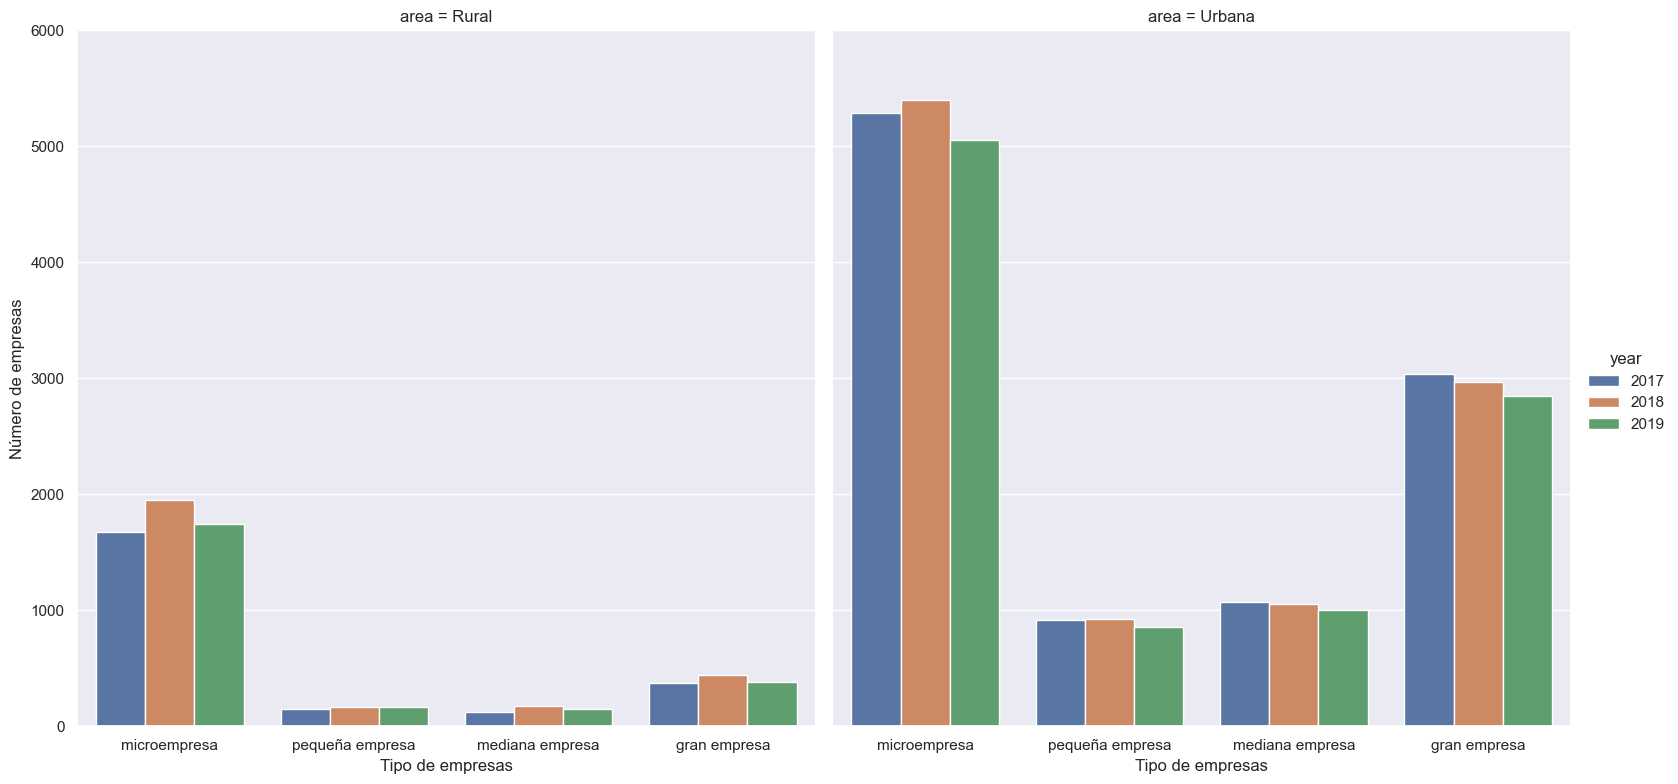

In [ ]:
# Gráfico de barras cruzado: cómo varía la variable empresa según el año y el área.

# catplot: Método de Seaborn que permite crear gráficos de barras a partir de un DataFrame de Pandas, con la posibilidad de cruzar varias variables.
# Haremos un ploteo de categorías.
ag = sns.catplot(x="empresa", 
                 hue="year", 
                 col= "area" , # col: partimos el gráfico por la variable área, creando un gráfico para cada área.
                 data= base2, 
                 kind="count", 
                 height=8, 
                 aspect=1);

# Eje x: Tipo de empresas
# Eje y: Número de empresas
(ag.set_axis_labels("Tipo de empresas", "Número de empresas")
  .set(ylim=(0, 6000))
  .despine(left=True)) 

## <a id ='1.3.'>1.3. Barras apiladas: Stack bar chart</a>

* Cuando las categorías están una sobre la otra en una misma barra.

In [ ]:
enaho['conglome']

0           0061
1           0110
2           0090
3           0118
4           3408
           ...  
160767    009703
160768    009675
160769    009703
160770    009700
160771    009645
Name: conglome, Length: 160772, dtype: object

In [ ]:
# Categorías de empresas doblemente capturadas porque nos separa por área:
enaho[ enaho['year'] == "2019" ].groupby( ['empresa', 'area'], observed=False ).size().reset_index(name='num_firms')

,empresa,area,num_firms
0,microempresa,Rural,1742
1,microempresa,Urbana,5056
2,pequeña empresa,Rural,169
3,pequeña empresa,Urbana,857
4,mediana empresa,Rural,145
5,mediana empresa,Urbana,1000
6,gran empresa,Rural,381
7,gran empresa,Urbana,2846


In [ ]:
# Convierto lo anterior a un objeto: base_2
base_2 = enaho[ enaho['year'] == "2019" ].groupby( [ 'empresa', 'area' ], observed=False ).size().reset_index(name='num_firms')
base_2

,empresa,area,num_firms
0,microempresa,Rural,1742
1,microempresa,Urbana,5056
2,pequeña empresa,Rural,169
3,pequeña empresa,Urbana,857
4,mediana empresa,Rural,145
5,mediana empresa,Urbana,1000
6,gran empresa,Rural,381
7,gran empresa,Urbana,2846


In [ ]:
# Pivoteo base_2: 
# Ahora la variable empresa será el índice y cada área será una columna, con los valores de num_firms.
base_3 = base_2.pivot(index = 'empresa', columns = 'area', values = 'num_firms')
base_3

area,Rural,Urbana
empresa,,
microempresa,1742,5056
pequeña empresa,169,857
mediana empresa,145,1000
gran empresa,381,2846


In [ ]:
# columns es un atributo de un DataFrame de Pandas que devuelve un objeto Index que contiene los nombres de las columnas del DataFrame. 
# En este caso, base_3.columns devolverá los nombres de las columnas 
base_3.columns

CategoricalIndex(['Rural', 'Urbana'], categories=['Rural', 'Urbana'], ordered=True, dtype='category', name='area')

Text(0.5, 0, ' ')

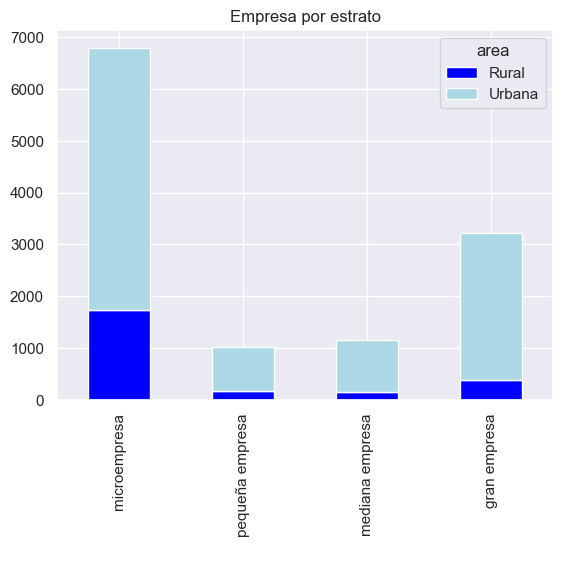

In [ ]:
# plot: Método de Pandas que permite crear gráficos a partir de los datos del DataFrame.
base_3.plot( kind='bar', stacked=True, title='Empresa por estrato', color = ['blue', 'lightblue'] )
plt.xlabel(' ')

# <a id ='2.'>II. Proporciones</a>

Understandable plots to show categorical variables. Use this plots to explain participations from categories. 

## <a id ='2.1.'>2.1. Gráfico de pie</a>

Hay dos formas de generar un gráfico de Pie:
* Matplotlib
* Pandas

In [ ]:
# Nos centramos en una variable:
base = enaho.groupby([ 'empresa' ], observed=False).count()
base

,year,conglome,vivienda,hogar,ubigeo,codperso,dominio,estrato,panel,p203,...,acumulado,estud,educa,d_edu,exper,exper_2,tenure_2,edad_2,jefe,ubigeo_2
empresa,,,,,,,,,,,,,,,,,,,,,
microempresa,58002,58002,58002,58002,58002,58002,58002,58002,58002,58002,...,57991,58002,57991,57991,57565,57565,58001,58002,58002,58002
pequeña empresa,9306,9306,9306,9306,9306,9306,9306,9306,9306,9306,...,9301,9306,9301,9301,9202,9202,9303,9306,9306,9306
mediana empresa,10304,10304,10304,10304,10304,10304,10304,10304,10304,10304,...,10302,10304,10302,10302,10212,10212,10304,10304,10304,10304
gran empresa,29642,29642,29642,29642,29642,29642,29642,29642,29642,29642,...,29639,29642,29639,29639,29392,29392,29640,29642,29642,29642


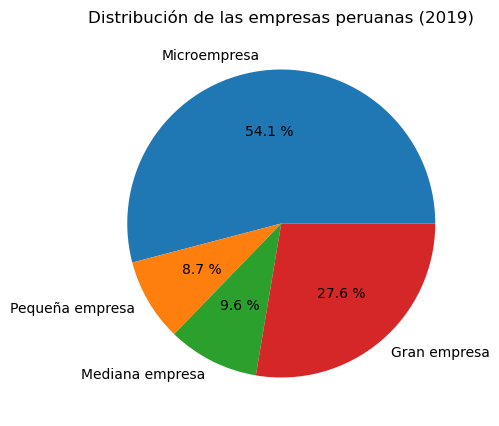

In [ ]:
# Etiquetas de las categorías para el gráfico de pastel:

labels=['Microempresa','Pequeña empresa' , 'Mediana empresa', 'Gran empresa']

# Graficamos con Matplotlib:
# plt: Clase de Matplotlib que permite crear gráficos a partir de los datos del DataFrame.
# figure: Método de Matplotlib
plt.figure(figsize=(5,5))

# conglome: Variable que contiene el número de empresas por categoría.
ax = plt.pie(base['conglome'], labels=labels, autopct='%.1f %%')
plt.title('Distribución de las empresas peruanas (2019)')
plt.show()

In [ ]:
# Ahora vemos la variable labor: Ocupaciones laborales
enaho.labor

0                                                       NaN
1                                   Ocupaciones elementales
2         Trabajo en actividades agrícolas, selvicultura...
3                                                       NaN
4                     Trabajadores de ventas y en servicios
                                ...                        
160767                                                  NaN
160768                              Ocupaciones elementales
160769                    Operadores de planta y maquinaria
160770                                                  NaN
160771                Trabajadores de ventas y en servicios
Name: labor, Length: 160772, dtype: category
Categories (9, object): ['Ocupaciones elementales' < 'Administradores' < 'Profesionales y fuerzas armadas' < 'Técnicos y similares' ... 'Trabajadores de ventas y en servicios' < 'Trabajo en actividades agrícolas, selvicultur... < 'Trabajo en artesanía y afines' < 'Operadores de planta y maquina

In [ ]:
base = enaho.groupby('labor', observed=True).size()
base

labor
Ocupaciones elementales                                   25556
Administradores                                           11310
Profesionales y fuerzas armadas                            1958
Técnicos y similares                                      12414
Asistentes administrativos                                14423
Trabajadores de ventas y en servicios                     18691
Trabajo en actividades agrícolas, selvicultura y pesca     5224
Trabajo en artesanía y afines                              8648
Operadores de planta y maquinaria                         11794
dtype: int64

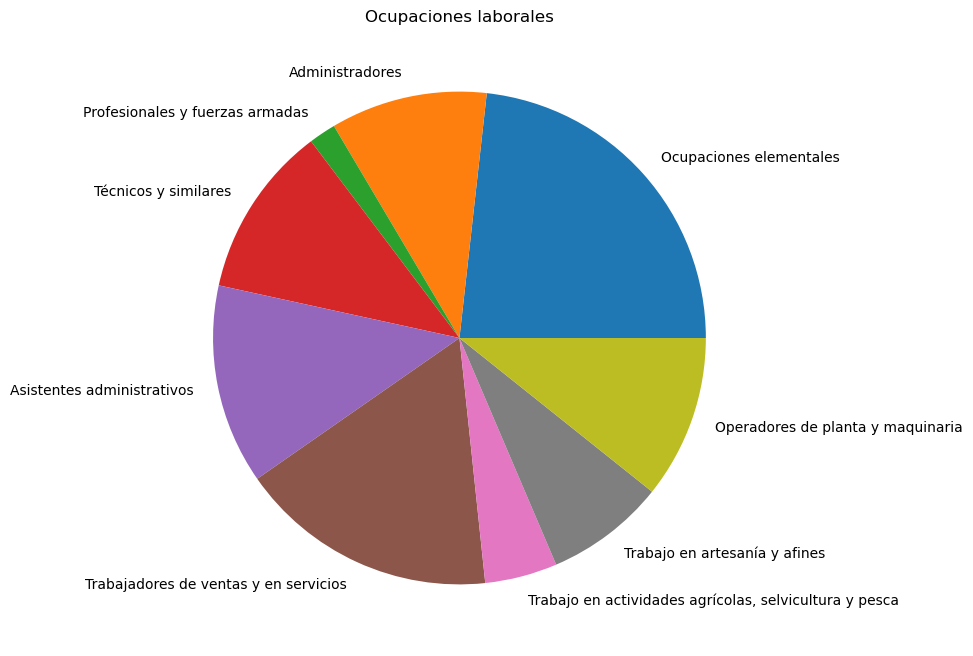

In [ ]:
# Graficamos con Pandas:

base = enaho.groupby('labor', observed=True).size()
base.plot(kind='pie', subplots=True, figsize=(8, 8))
plt.title("Ocupaciones laborales")
plt.ylabel("")
plt.show()

## <a id ='2.2.'>2.2. Gráfico de donuts</a>

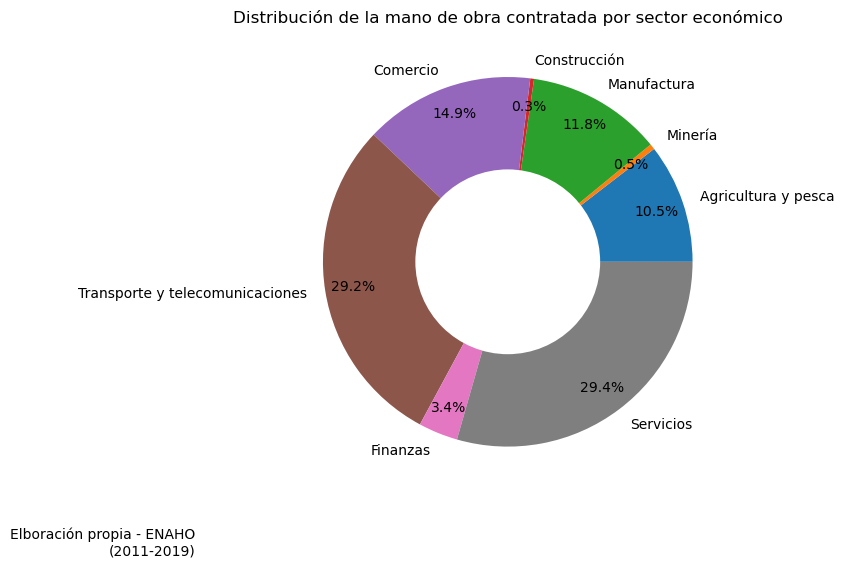

In [ ]:
base2 = enaho.groupby(['sector'], observed=True).count()

labels=['Agricultura y pesca','Minería','Manufactura','Construcción','Comercio','Transporte y telecomunicaciones', 'Finanzas', 'Servicios']
plt.figure(figsize=(10, 6))

ax = plt.pie(base2['conglome'], labels=labels,
        autopct='%1.1f%%', pctdistance=0.85)
  
# centroid size and color

center_circle = plt.Circle((0, 0), 0.50, fc='white')
fig = plt.gcf()

fig.gca().add_artist(center_circle)
  
plt.title('Distribución de la mano de obra contratada por sector económico')

# Adding notes

txt="Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.2, 0.01, txt, wrap=True, horizontalalignment='right', fontsize=10)

plt.show()

## <a id ='3.'>III. Distribuciones</a>

* Los gráficos de distribución evalúan visualmente la distribución de los datos de la muestra al comparar la distribución empírica de los datos con los valores teóricos esperados de una distribución específica

## <a id ='3.1.'>3.1. Histogramas simples</a>

* En logaritmos, el salario normalmente tiene una distribución normal.

Text(0.5, 1.0, 'Logaritmo de la distribución de los salarios')

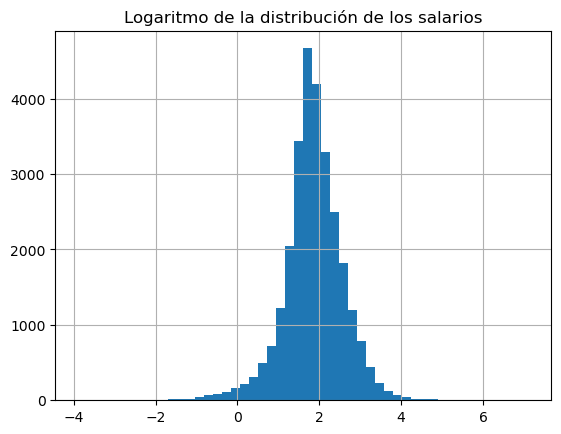

In [ ]:
# Usamos la base2: Contiene los datos de 2017 en adelante
# bins: Número de intervalos en los que se divide el rango de la variable para crear un histograma.
base2.l_salario.hist(bins=50)
plt.title('Logaritmo de la distribución de los salarios')

* Logaritmo del salario implica reescalar la data para evitar outliers.
* Da negativo porque en realidad está cercano a 0.

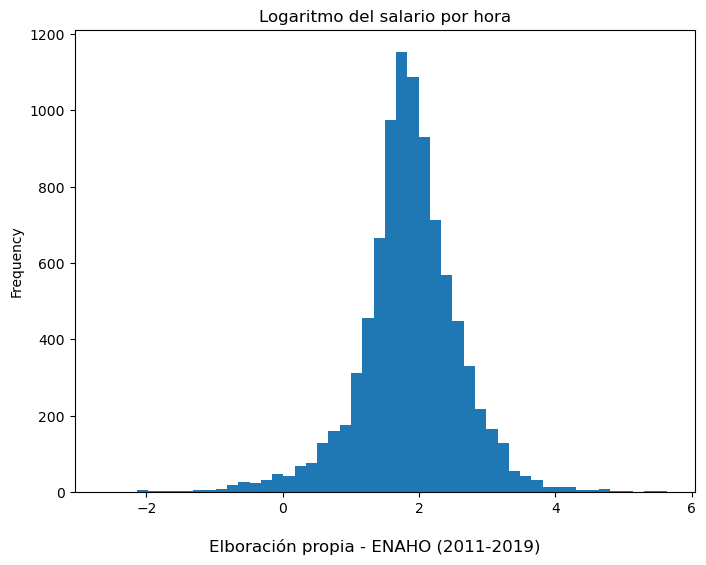

In [ ]:
# Filtramos datos del 2019 en adelante: base4
base4 = enaho[enaho['year'] == "2019" ]

base4['l_salario'].plot(kind = 'hist', bins = 50, figsize = (8,6))
plt.title('Logaritmo del salario por hora')

txt="Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

## <a id ='3.2.'>3.2. Histogramas múltiples</a>

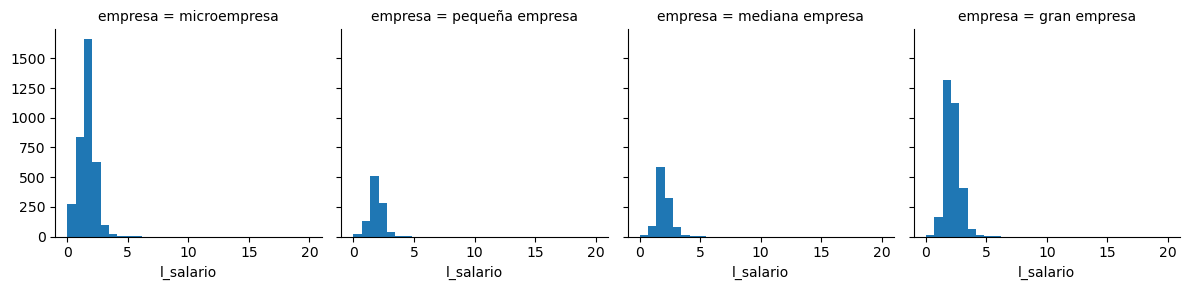

In [ ]:
# Histogramas agrupados por tipo de empresa

figure1 = sns.FacetGrid(base4, col="empresa", margin_titles=True)
figure1.map(plt.hist, 'l_salario', bins=np.linspace(0, 20, 30))

## <a id ='3.3.'>3.3. Mapas de densidad</a>

* **Salario por hora:** La información observable son las variables de alto valor, pero la mayoría de información son las de bajo valor.

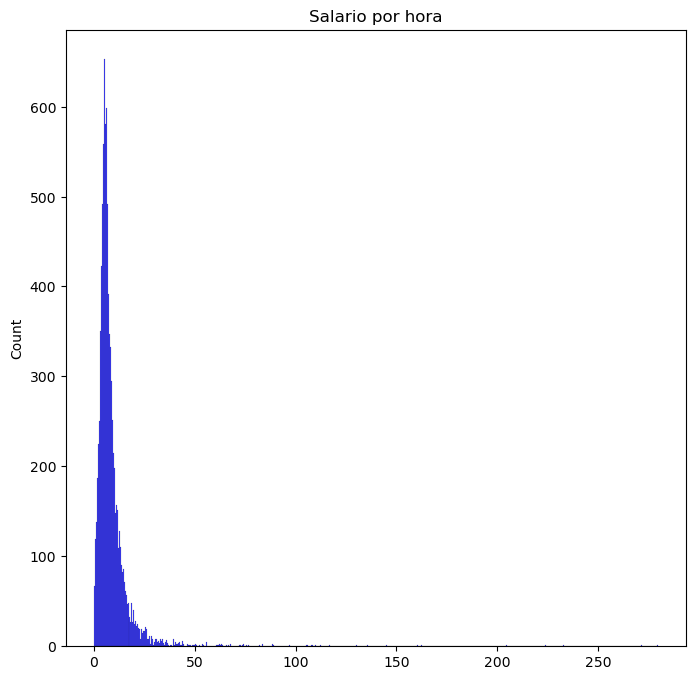

In [ ]:
plt.figure(figsize=(8, 8))

sns.histplot(base4['salario'], label = "Densidad", color = 'blue')
plt.title('Salario por hora')
plt.xlabel(' ')
plt.show()

* **Logaritmo del Salario por hora:** Corregimos lo anterior, siguiendo la misma dinámica que la variable Ingreso.

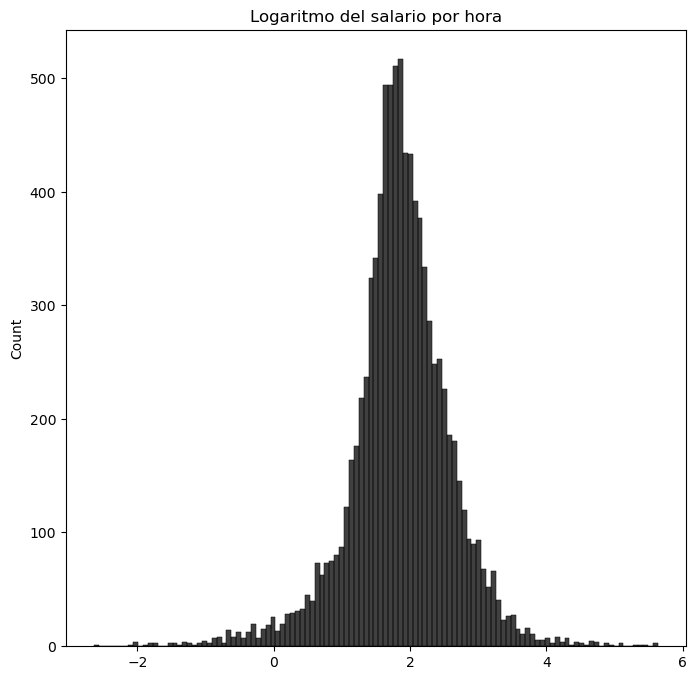

In [ ]:
#Alternative figure size
plt.figure(figsize=(8, 8))

sns.histplot(base4['l_salario'], label = "Densidad", color = 'black')
plt.title('Logaritmo del salario por hora')
plt.xlabel(' ')
plt.show()

* Logaritmo del Salario en tres sectores: Construcción, Comercio y Minería

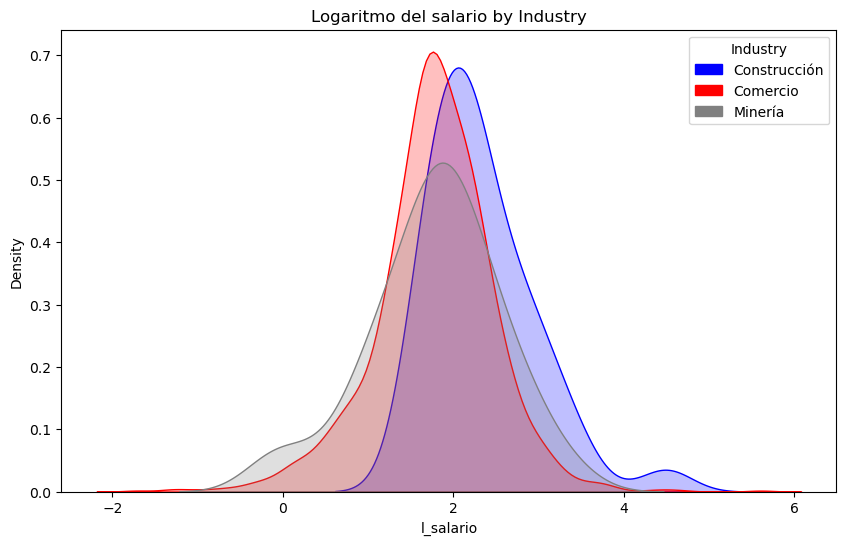

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))

#Adding densities 

sns.kdeplot(base4.l_salario[base4.sector=='Construcción'], label='Construcción', fill=True, color="blue")
sns.kdeplot(base4.l_salario[base4.sector=='Comercio, hoteles y restaurantes'], label='Comercio, hoteles y restaurantes', fill=True, color = "red")
sns.kdeplot(base4.l_salario[base4.sector=='minería'], label='Minería ', fill=True, color="gray")
plt.title('Logaritmo del salario by Industry')

# Define custom colors
color1 = 'blue'
color2 = 'red'
color3 = "gray"
# Create legend handles
handle1 = mpatches.Patch(color=color1, label='Construcción')
handle2 = mpatches.Patch(color=color2, label='Comercio')
handle3 = mpatches.Patch(color=color3, label='Minería')

# Manually adding a legend with custom colors
plt.legend(handles=[handle1, handle2, handle3], title='Industry')
# Construction sector shows certain stochastic dominance over mining and services

* **Un For loop producirá el mismo mapa:** Usemos otros sectores para ejemplificar

Text(0.5, 0, 'Logaritmo del salario por tipo de ocupación')

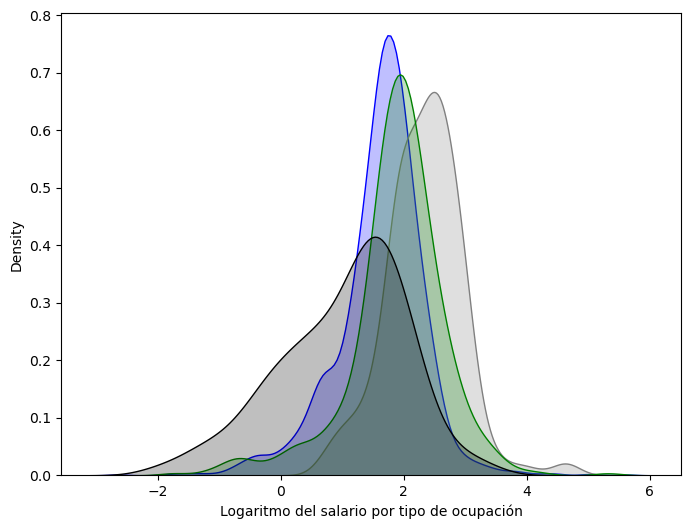

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

sector = [ 'Ocupaciones elementales', 'Profesionales y fuerzas armadas', 'Operadores de planta y maquinaria',
          'Trabajo en actividades agrícolas, selvicultura y pesca']

nombre = [ 'Ocupaciones elementales', 'Profesionales', 'Planta y maquinaria','Actividades extractivas']

color = [ 'blue', 'gray', 'green','black']

    
for a, b, c in zip(sector, nombre, color):
        sns.kdeplot(base4.l_salario[base4.labor==a], label=b, fill=True, color = c)

plt.xlabel('Logaritmo del salario por tipo de ocupación')

# Dos hallazgos relevantes: dominancia estocástica del salario de los profesionales y concentración en los niveles salariales más bajos en el sector primario inactivo.

## <a id ='3.4.'>3.4. Diagrama de Cajas</a>

### Box plot real salary and education 



[Text(0, 0, 'Sec. completa'),
 Text(1, 0, 'No uni. incompleta'),
 Text(2, 0, 'No uni. completa'),
 Text(3, 0, 'Uni. incompleta'),
 Text(4, 0, 'Uni. completa'),
 Text(5, 0, 'Posgrado')]

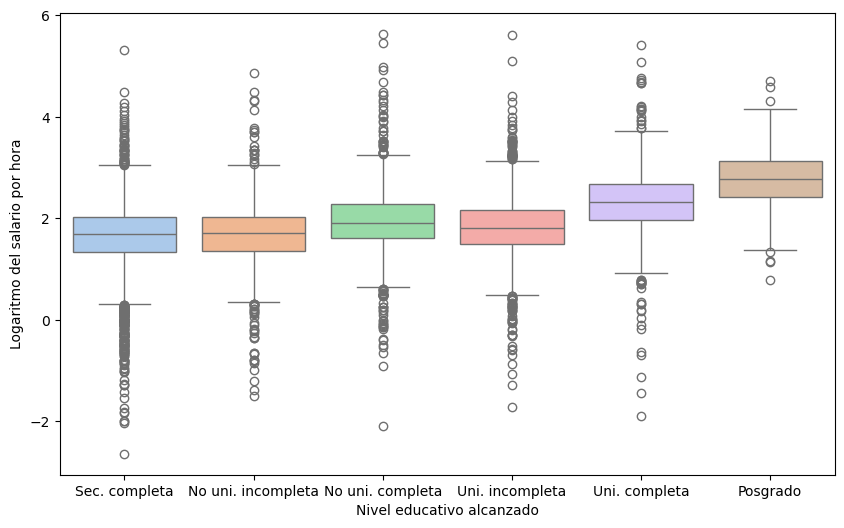

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# 1. Agregamos hue="educ" y legend=False para silenciar la advertencia de Seaborn
box = sns.boxplot(x="educ", y="l_salario", hue="educ", data=enaho[enaho['year'] == "2019"], palette='pastel', legend=False)

plt.xlabel('Nivel educativo alcanzado')
plt.ylabel('Logaritmo del salario por hora')

# 2. Definimos primero la posición de las marcas (ticks) y luego los textos para silenciar la advertencia de Matplotlib
etiquetas = ["Sec. completa", "No uni. incompleta", "No uni. completa", "Uni. incompleta", "Uni. completa", "Posgrado"]
box.set_xticks(range(len(etiquetas)))
box.set_xticklabels(etiquetas)

# Los cuartiles del salario real aumentan con el nivel educativo.
# Menor dispersión salarial para el nivel de posgrado.

# <a id ='4.'>IV. Relaciones</a>

Charts used for both time series and cross-sectional data. These graphs allow to establish certain evidence of correlation or relationships between variables.

## <a id ='4.1.'>4.1. Diagrama de puntos: Scatter plot </a>

First, a random sample is drawn from the original database. Subsequently, a dispersion graph is presented between the hourly wage (logarithm) and the non-labor monthly income (logarithm).

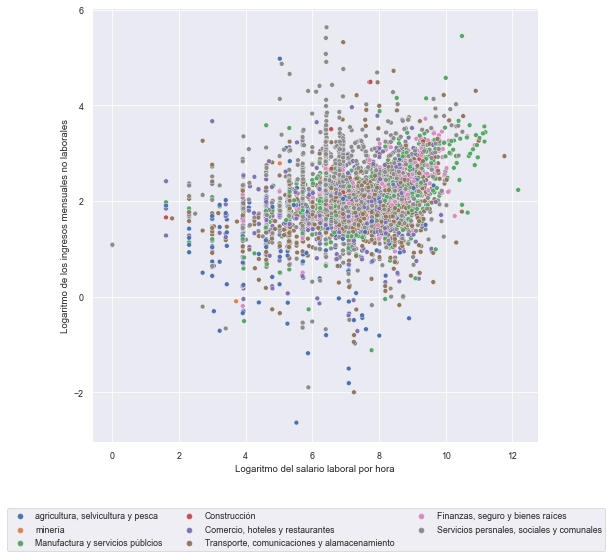

In [ ]:
#Full sample

sns.set('paper')
plt.figure(figsize=(8, 8))
plot = sns.scatterplot(data=base4, x="l_n_labor", y="l_salario", hue="sector", palette="deep")

plt.xlabel('Logaritmo del salario laboral por hora')
plt.ylabel('Logaritmo de los ingresos mensuales no laborales')

# By default legend inside plot. Following codes allow us to put outside. 
# bbox_to_anchor: box location
# ncol: # columns of legend



plot.legend(loc='center left', bbox_to_anchor=(-0.2, -0.2), ncol=3)

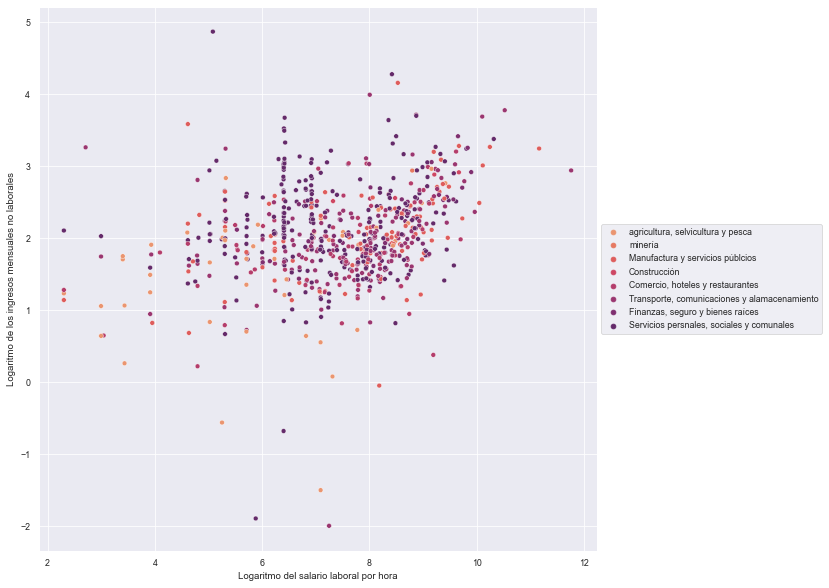

In [ ]:
# Ramdon sample n = 3000

base5 = base4.sample(n = 3000)

sns.set('paper')
plt.figure(figsize=(10, 10))
plot = sns.scatterplot(data=base5, x="l_n_labor", y="l_salario", hue="sector", palette="flare")

plt.xlabel('Logaritmo del salario laboral por hora')
plt.ylabel('Logaritmo de los ingresos mensuales no laborales')

plot.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

#### Reggresion real salary per hour and  non-labor income by strata

s = The marker size in points**2. <br>
linewidths = "The linewidth of the marker edges."

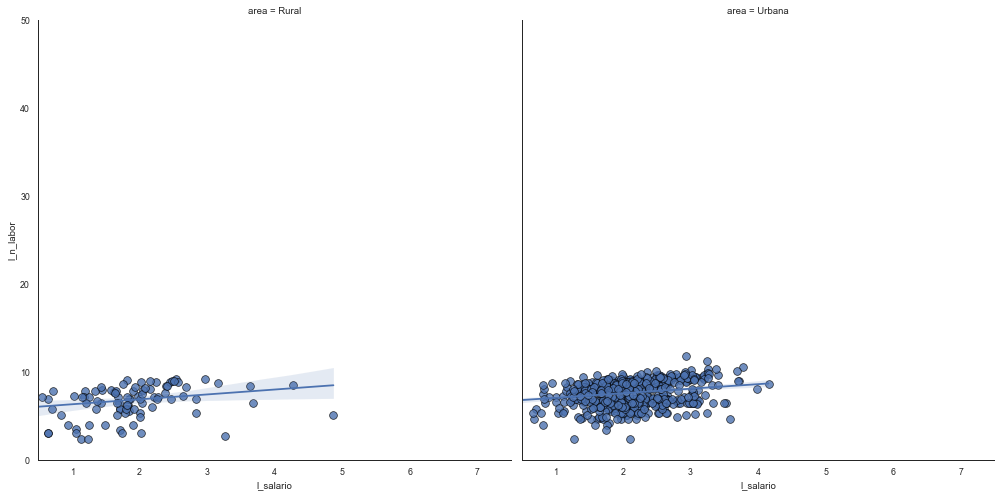

In [ ]:
sns.set_style("white")
gridobj = sns.lmplot(x="l_salario", y="l_n_labor", 
                     data=base5, 
                     height=7, 
                     robust=True, 
                     palette='Set1', 
                     col="area",
                     scatter_kws=dict(s=60, linewidths=0.7, edgecolors='black'))

gridobj.set(xlim=(0.5, 7.5), ylim=(0, 50))
plt.show()

<Axes: xlabel='l_salario', ylabel='l_n_labor'>

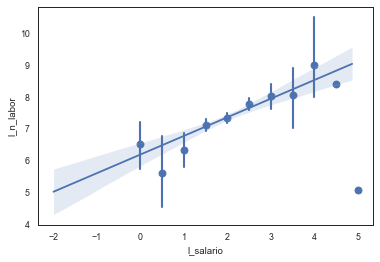

In [ ]:
sns.regplot(data=base5, x="l_salario", y="l_n_labor", x_bins=np.arange(0, 7, 0.5), order=1)

## Macroeconomics 
IMP: log-Commodity price index, TC: log-exchange rate, RIN: log-international reserves, IPC: log-price consumption index, RATE: central bank rate reference

D: Annual difference

In [ ]:
macro = pd.read_csv(r"../_data/macroeconomia.csv")
macro['YEAR']  = pd.to_datetime(macro['Fecha'])
macro

,Fecha,IPM,TC,RIN,IPC,RATE,DIPM,DTC,DRIN,DIPC,YEAR
0,2003-1,2.83506,1.25634,9.18519,4.41828,3.7500,13.73166,0.83108,12.50532,2.25690,2003-01-01
1,2003-2,2.85371,1.25004,9.21777,4.42295,3.8000,12.48664,0.16400,13.17984,2.76396,2003-02-01
2,2003-3,2.84717,1.24993,9.24303,4.43407,3.8200,7.76170,0.65330,17.18115,3.33857,2003-03-01
3,2003-4,2.80982,1.24554,9.24188,4.43356,3.8400,1.97256,0.69980,13.92729,2.56103,2003-04-01
4,2003-5,2.88617,1.24686,9.23065,4.43324,3.7800,6.81493,0.92160,12.37214,2.39028,2003-05-01
...,...,...,...,...,...,...,...,...,...,...,...
199,2019-8,3.74485,1.22252,11.12236,4.88368,2.5642,3.71183,2.73013,12.37958,2.01920,2019-08-01
200,2019-9,3.74443,1.20844,11.12124,4.88375,2.5038,7.63091,1.29986,15.82517,1.83408,2019-09-01
201,2019-10,3.70510,1.20622,11.13029,4.88486,2.5045,0.48716,0.71850,15.12033,1.86310,2019-10-01
202,2019-11,3.69955,1.20500,11.11988,4.88594,2.2984,0.97267,-0.08858,11.80591,1.84959,2019-11-01


Text(0.5, 0.01, 'Elboración propia - BCRP')

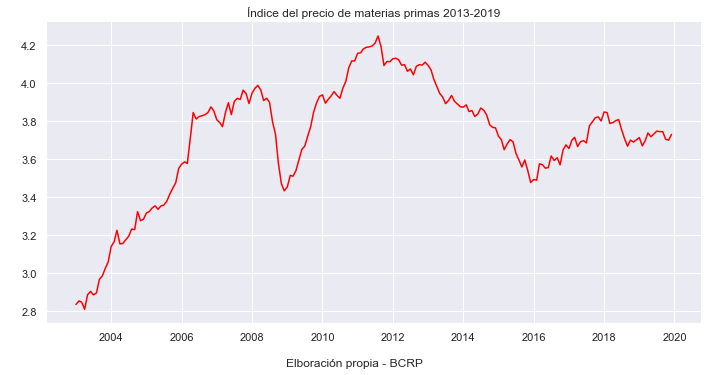

In [ ]:
sns.set('notebook')

sns.relplot(x="YEAR", y="IPM", kind="line", color="red", data=macro, height=5, aspect=2)
plt.xlabel(' ')
plt.ylabel(' ')
plt.title('Índice del precio de materias primas 2013-2019')

txt="Elboración propia - BCRP"  
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=12)

#### Series in a single image

This graph shows a positive relationship between the change in international reserves and the commodity index.

Text(0.2, 0.01, 'Elaboración propia - BCRP')

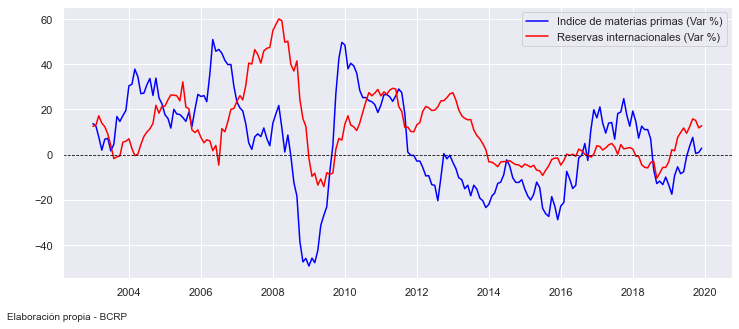

In [ ]:
sns.set('notebook')


fig, ax = plt.subplots(figsize=(12,5))

x = macro['YEAR']
y1 = macro['DIPM']
y2 = macro['DRIN']

plt.plot(x, y1, label ='Indice de materias primas (Var %)', color='blue')
plt.plot(x, y2, label ='Reservas internacionales (Var %)', color='red')
plt.axhline(y=0, color='black', linestyle='--', lw=0.8)

plt.legend(loc='upper right')

txt="Elaboración propia - BCRP"  
plt.figtext(0.2, 0.01, txt, wrap=True, horizontalalignment='right', fontsize=10)

### Dual-line Plots

#### Exchange rate and monetary policy reaction

Text(0.2, 0.01, 'Elboración propia - BCRP')

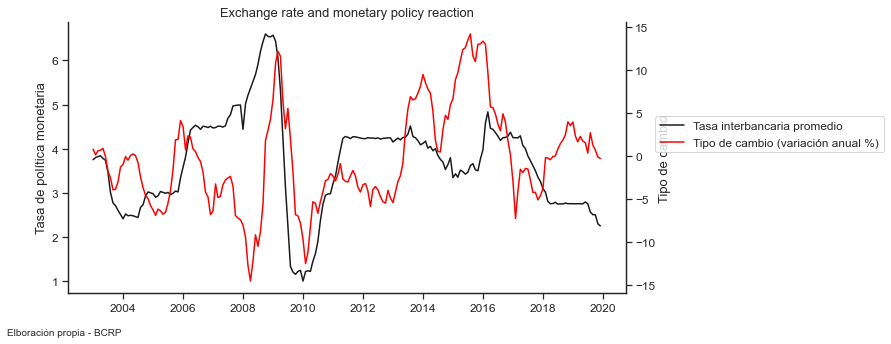

In [ ]:
sns.set('notebook', style = "ticks", font_scale= 1.08)

fig, ax = plt.subplots(figsize=(10,5))
lineplot = sns.lineplot(x= "YEAR" , y= "RATE", data=macro, 
                        label = 'Tasa interbancaria promedio ', color="k", legend=False)

#sns.despine()
plt.ylabel('Tasa de política monetaria')
plt.xlabel(' ')
plt.title('Exchange rate and monetary policy reaction');

ax2 = ax.twinx()
lineplot2 = sns.lineplot(x= "YEAR", y= "DTC", data=macro, ax=ax2, color = "red", 
                         label ='Tipo de cambio (variación anual %)', legend=False) 
sns.despine(right=False)
plt.ylabel('Tipo de cambio')
ax.figure.legend(loc='lower center', bbox_to_anchor=(1.1, 0.5), ncol=1);


txt="Elboración propia - BCRP"  
plt.figtext(0.2, 0.01, txt, wrap=True, horizontalalignment='right', fontsize=10)

#### Reference:

#### Library of plots 

https://www.python-graph-gallery.com/stacked-and-percent-stacked-barplot

#### Seaborn package:

https://seaborn.pydata.org/generated/seaborn.catplot.html

https://programmerclick.com/article/54791895404/